In [1]:
import pandas, numpy, seaborn, random

In [2]:
import scipy, scipy.stats

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# Generate the expression

We are going to generate a random expression matrix with a certain structure, to visualize a nice pattern.  
In a real-case scenario you will be probably reading a tsv or excel file with pandas

In [4]:
number_of_genes = 20
numpy.random.seed(512)
x = numpy.random.random((number_of_genes, 9))
my_columns = ['condA_rep1', 'condA_rep2', 'condA_rep3', 'condB_rep1', 'condB_rep2', 'condB_rep3', 'condC_rep1', 'condC_rep2', 'condC_rep3']
my_index = ['ENS{:03d}'.format(i) for i in range(number_of_genes)]
random.shuffle(my_index)
df = pandas.DataFrame(data=x, index=my_index, columns=my_columns)

df.iloc[:5, :3] = df.iloc[:5, :3]+10
df.iloc[5:10, 3:6] = df.iloc[5:10, 3:6]*100
df.iloc[10:15, 6:9] = df.iloc[10:15, 6:9]*1000

df.sort_index(ascending=True, inplace=True)

It is not necessary that you understand how this test data is generated. But let's have a look to it!

In [5]:
df

,condA_rep1,condA_rep2,condA_rep3,condB_rep1,condB_rep2,condB_rep3,condC_rep1,condC_rep2,condC_rep3
ENS000,0.437895,0.608120,0.657936,0.408826,0.208895,0.790629,0.925053,0.845143,0.599231
ENS001,0.496446,0.817395,0.876227,0.404395,15.558020,21.699243,0.830586,0.884334,0.517694
ENS002,0.702829,0.706138,0.700758,0.342924,0.036027,0.653404,527.534880,996.670256,146.933451
ENS003,0.881655,0.232620,0.740352,0.222589,0.958938,0.802988,0.671276,0.872996,0.720255
ENS004,0.570615,0.163580,0.192869,29.901903,22.517788,22.594885,0.794317,0.534955,0.869193
ENS005,0.667948,0.914006,0.159719,0.900828,0.827319,0.799820,976.627002,762.335565,984.540836
ENS006,0.403734,0.825820,0.828071,94.482060,84.901267,60.034704,0.501914,0.449563,0.900484
ENS007,0.706568,0.258055,0.011802,0.870612,0.710948,0.814187,950.834093,912.893630,87.341991
ENS008,10.401963,10.318341,10.419603,0.127848,0.320888,0.158819,0.914869,0.240554,0.800907
ENS009,0.556854,0.923165,0.334890,0.757095,0.419476,0.618040,0.129560,0.814717,0.819685


# Let's cluster the expression!

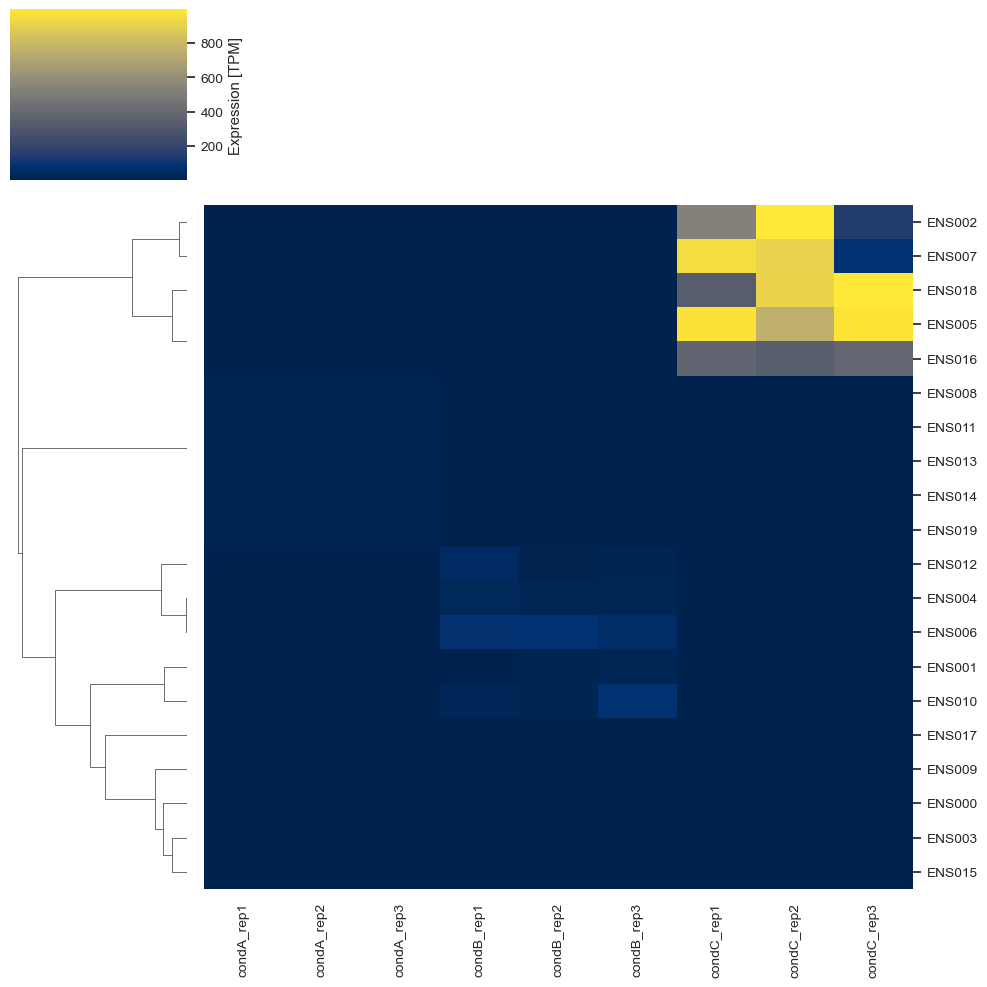

In [6]:
linkage_method = 'complete'
distance_metric = 'cosine'

seaborn.set(font_scale=0.9)
seaborn.clustermap(df, 
                   cmap='cividis',         # why? this is important, check https://matplotlib.org/stable/users/explain/colors/colormaps.html
                   col_cluster=False,      # would you cluster the colums too?
                   method=linkage_method, 
                   metric=distance_metric, 
                   yticklabels=1, 
                   cbar_kws={'label':'Expression [TPM]'})
matplotlib.pyplot.tight_layout()

# Let's think...

Is there anything we could to to improve the heatmap?

In [7]:
zdf = scipy.stats.zscore(df, axis=1) # do you think axis=1 is important, why?
zdf

,condA_rep1,condA_rep2,condA_rep3,condB_rep1,condB_rep2,condB_rep3,condC_rep1,condC_rep2,condC_rep3
ENS000,-0.791905,-0.004447,0.226003,-0.926377,-1.851260,0.839840,1.461686,1.092024,-0.045564
ENS001,-0.550017,-0.507781,-0.500039,-0.562130,1.432023,2.240182,-0.506045,-0.498972,-0.547221
ENS002,-0.561124,-0.561114,-0.561130,-0.562214,-0.563143,-0.561274,1.033980,2.454395,-0.118377
ENS003,0.797715,-1.746864,0.243725,-1.786190,1.100707,0.489296,-0.027090,0.763766,0.164934
ENS004,-0.692367,-0.727110,-0.724610,1.811205,1.180933,1.187514,-0.673273,-0.695411,-0.666882
ENS005,-0.700477,-0.699907,-0.701654,-0.699937,-0.700107,-0.700171,1.560092,1.063739,1.578422
ENS006,-0.696390,-0.685354,-0.685295,1.763568,1.513049,0.862839,-0.693823,-0.695192,-0.683401
ENS007,-0.565054,-0.566225,-0.566868,-0.564626,-0.565043,-0.564773,1.915262,1.816218,-0.338891
ENS008,1.416789,1.398993,1.420544,-0.769788,-0.728704,-0.763196,-0.602291,-0.745801,-0.626545
ENS009,-0.162650,1.319457,-1.060721,0.647531,-0.718485,0.084914,-1.891493,0.880673,0.900773


In [8]:
### what am I doing here?
print(numpy.sum(zdf.iloc[1, :]))
print(numpy.std(zdf.iloc[1, :]))

-1.3322676295501878e-15
0.9999999999999999


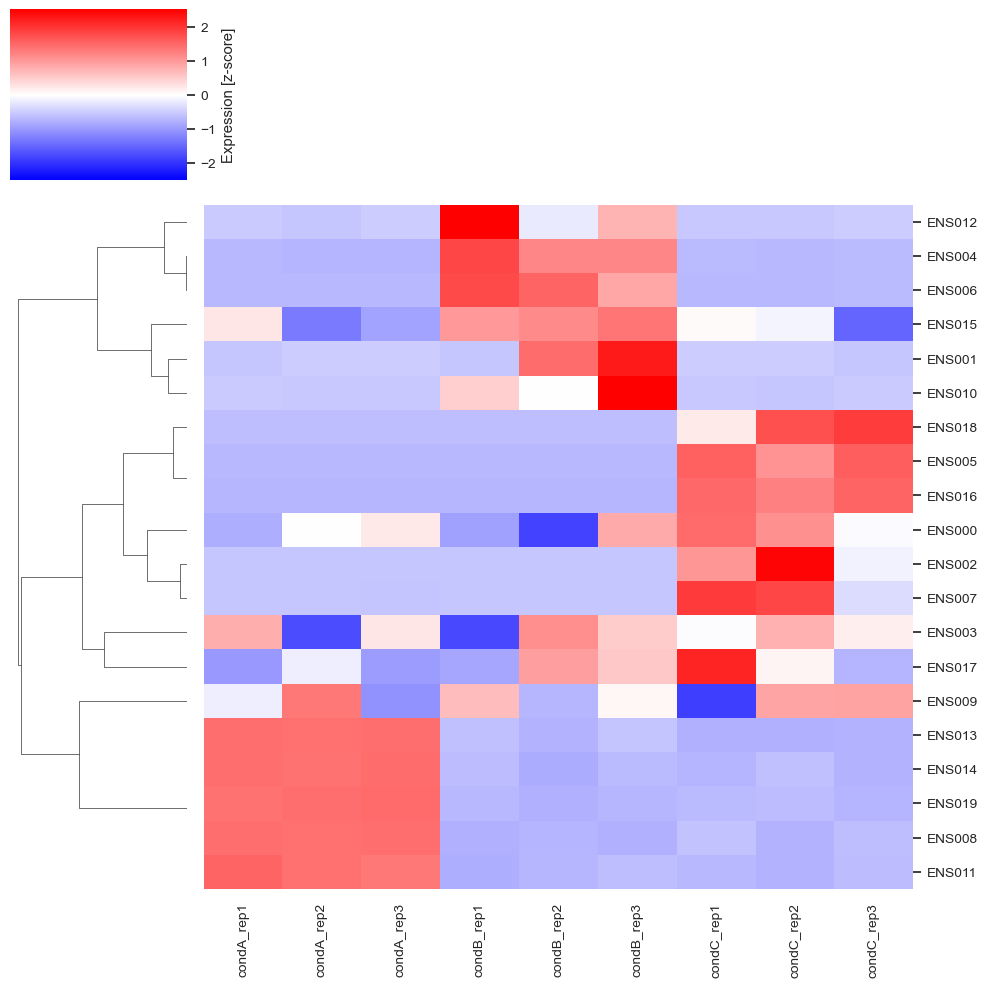

In [9]:
linkage_method = 'complete'
distance_metric = 'cosine'

seaborn.set(font_scale=0.9)
seaborn.clustermap(zdf, 
                   cmap='bwr',       # why now a different color scale?  
                   col_cluster=False, 
                   vmin=-2.5, vmax=2.5,   # why this is important? how did I selected these values? 
                   method=linkage_method, 
                   metric=distance_metric, 
                   yticklabels=1, 
                   cbar_kws={'label':'Expression [z-score]'})
matplotlib.pyplot.tight_layout()

# Let's think (again, sorry)

Is there anything we could to to improve the heatmap?

In [10]:
no_noise = df[df.max(axis=1) > 2] # what am I doing here?

In [11]:
zdf = scipy.stats.zscore(no_noise, axis=1)

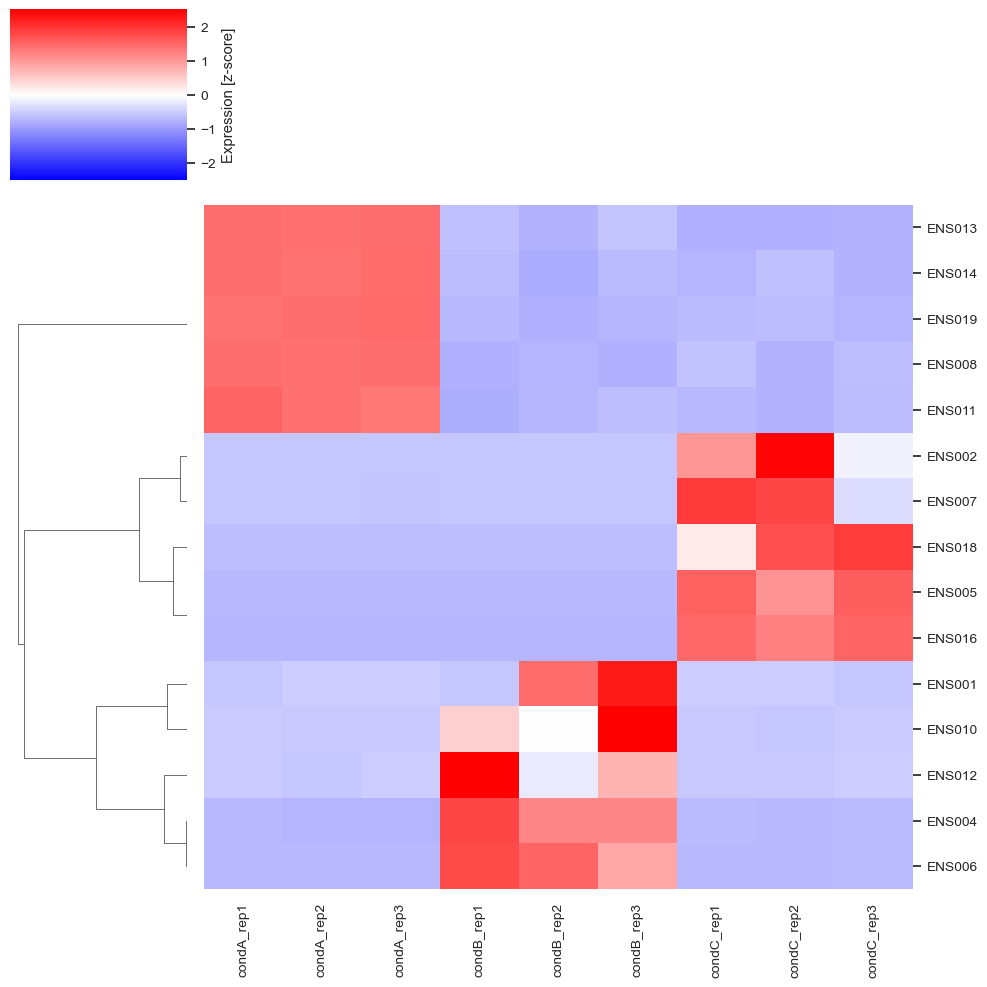

In [12]:
linkage_method = 'complete'
distance_metric = 'cosine'

seaborn.set(font_scale=0.9)
seaborn.clustermap(zdf, 
                   cmap='bwr',       
                   col_cluster=False, 
                   vmin=-2.5, vmax=2.5,   
                   method=linkage_method, 
                   metric=distance_metric, 
                   yticklabels=1, 
                   cbar_kws={'label':'Expression [z-score]'})
matplotlib.pyplot.tight_layout()

# Closing remarks

As a homework practice, consider building the histogram of the expression distribution. Next, build a histogram of the expression distribution that justifies performing the z-score transformation.

Take home message: finding patterns is fun and sometimes tricky. But hey, now you know how to build heatmaps. Stay critical.